# MobileNetV2 3-Class Image Classification with Keras - Center Crop

This notebook trains a 3-class classifier using `MobileNetV2` transfer learning with a configurable `alpha` width multiplier.

Images are center-cropped to the target aspect ratio before resizing, matching a `320x240 -> center 240x240 -> 160x160` ESP32 preprocessing path.

In [6]:
from pathlib import Path
from typing import List
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print('TensorFlow:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.10.0
GPU available: True


In [7]:
SEED = 42
IMAGE_SIZE = (160, 160)
BATCH_SIZE = 16
HEAD_EPOCHS = 10
FINETUNE_EPOCHS = 10
ALPHA = 0.35
CLASS_NAMES = ['Amine', 'Rifki', 'Jakub']
DATA_ROOT = Path('../data')
MODEL_PATH = Path('saved_model/mobilenetv2_3class_center_crop_classifier.keras')

keras.utils.set_random_seed(SEED)

if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Could not find dataset directory: {DATA_ROOT.resolve()}')

print('Data root:', DATA_ROOT.resolve())
print('Alpha:', ALPHA)

Data root: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\data
Alpha: 0.35


In [8]:
def collect_split_dataframe(data_root: Path, class_names: List[str], split: str) -> pd.DataFrame:
    records = []
    valid_ext = {'.png', '.jpg', '.jpeg', '.bmp'}

    for class_name in class_names:
        split_dir = data_root / class_name / split
        if not split_dir.exists():
            raise FileNotFoundError(f'Missing split directory: {split_dir}')

        for file_path in sorted(split_dir.iterdir()):
            if file_path.is_file() and file_path.suffix.lower() in valid_ext:
                records.append({'filepath': str(file_path), 'label': class_name})

    if not records:
        raise ValueError(f'No images found for split={split!r}')

    df = pd.DataFrame(records)
    return df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


train_df = collect_split_dataframe(DATA_ROOT, CLASS_NAMES, 'train')
test_df = collect_split_dataframe(DATA_ROOT, CLASS_NAMES, 'test')

display(train_df.head())
print('Train samples:', len(train_df))
print(train_df['label'].value_counts().sort_index())
print()
print('Test samples:', len(test_df))
print(test_df['label'].value_counts().sort_index())

,filepath,label
0,..\data\Jakub\train\image_20260314_150704.png,Jakub
1,..\data\Amine\train\image_20260321_204014_brig...,Amine
2,..\data\Jakub\train\image_20260314_145634_comp...,Jakub
3,..\data\Rifki\train\image_20260312_074812_occl...,Rifki
4,..\data\Rifki\train\image_20260305_130316_hfli...,Rifki


Train samples: 2160
label
Amine    720
Jakub    720
Rifki    720
Name: count, dtype: int64

Test samples: 540
label
Amine    180
Jakub    180
Rifki    180
Name: count, dtype: int64


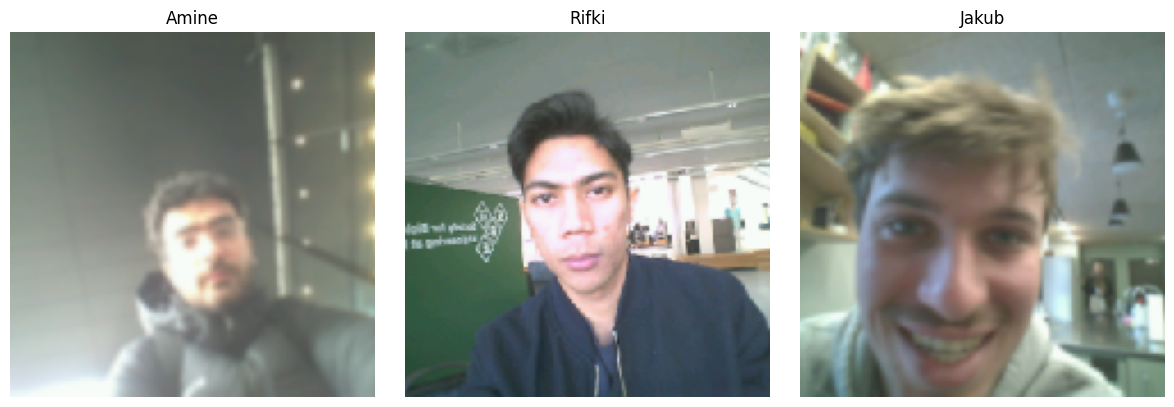

In [9]:
sample_paths = []
for class_name in CLASS_NAMES:
    class_rows = train_df[train_df['label'] == class_name]
    sample_paths.append(class_rows.sample(1, random_state=SEED).iloc[0]['filepath'])

plt.figure(figsize=(12, 4))
for i, image_path in enumerate(sample_paths, start=1):
    image = keras.utils.load_img(image_path, target_size=IMAGE_SIZE, keep_aspect_ratio=True)
    plt.subplot(1, len(sample_paths), i)
    plt.imshow(image)
    plt.title(Path(image_path).parts[-3])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=12,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True,
)

test_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    keep_aspect_ratio=True,
    class_mode='categorical',
    classes=CLASS_NAMES,
    subset='training',
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True,
)

val_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    keep_aspect_ratio=True,
    class_mode='categorical',
    classes=CLASS_NAMES,
    subset='validation',
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False,
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    keep_aspect_ratio=True,
    class_mode='categorical',
    classes=CLASS_NAMES,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print('Class indices:', train_gen.class_indices)

Found 1728 validated image filenames belonging to 3 classes.
Found 432 validated image filenames belonging to 3 classes.
Found 540 validated image filenames belonging to 3 classes.
Class indices: {'Amine': 0, 'Rifki': 1, 'Jakub': 2}


In [11]:
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=IMAGE_SIZE + (3,),
    alpha=ALPHA,
)
base_model.trainable = False

inputs = keras.Input(shape=IMAGE_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation='softmax')(x)

model = keras.Model(inputs, outputs, name='MobileNetV2_3Class')
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy'],
)


model.summary()

Model: "MobileNetV2_3Class"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 mobilenetv2_0.35_160 (Funct  (None, 5, 5, 1280)       410208    
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout_1 (Dropout)         (None, 128)        

In [12]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True),
]

history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks,
)

model = keras.models.load_model(MODEL_PATH)

Epoch 1/10
108/108 [==============================] - 12s 92ms/step - loss: 0.5526 - accuracy: 0.8704 - val_loss: 0.3946 - val_accuracy: 0.9722 - lr: 0.0010
Epoch 2/10
108/108 [==============================] - 8s 76ms/step - loss: 0.3950 - accuracy: 0.9763 - val_loss: 0.3485 - val_accuracy: 0.9861 - lr: 0.0010
Epoch 3/10
108/108 [==============================] - 14s 134ms/step - loss: 0.3723 - accuracy: 0.9815 - val_loss: 0.3403 - val_accuracy: 0.9977 - lr: 0.0010
Epoch 4/10
108/108 [==============================] - 9s 81ms/step - loss: 0.3636 - accuracy: 0.9913 - val_loss: 0.3297 - val_accuracy: 0.9907 - lr: 0.0010
Epoch 5/10
108/108 [==============================] - 8s 74ms/step - loss: 0.3526 - accuracy: 0.9902 - val_loss: 0.3235 - val_accuracy: 0.9931 - lr: 0.0010
Epoch 6/10
108/108 [==============================] - 8s 75ms/step - loss: 0.3475 - accuracy: 0.9971 - val_loss: 0.3222 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 7/10
108/108 [==============================] - 8s 74ms

In [13]:
base_model = model.layers[1]
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=FINETUNE_EPOCHS,
    callbacks=callbacks,
)

model = keras.models.load_model(MODEL_PATH)

Epoch 1/10
108/108 [==============================] - 10s 79ms/step - loss: 0.1065 - accuracy: 0.9959 - val_loss: 0.0827 - val_accuracy: 1.0000 - lr: 1.0000e-06
Epoch 2/10
108/108 [==============================] - 9s 87ms/step - loss: 0.0875 - accuracy: 0.9971 - val_loss: 0.0661 - val_accuracy: 1.0000 - lr: 1.0000e-06
Epoch 3/10
108/108 [==============================] - 8s 74ms/step - loss: 0.0768 - accuracy: 0.9959 - val_loss: 0.0499 - val_accuracy: 1.0000 - lr: 1.0000e-06
Epoch 4/10
108/108 [==============================] - 8s 76ms/step - loss: 0.0705 - accuracy: 0.9959 - val_loss: 0.0499 - val_accuracy: 1.0000 - lr: 1.0000e-06
Epoch 5/10
108/108 [==============================] - 8s 74ms/step - loss: 0.0624 - accuracy: 0.9936 - val_loss: 0.0435 - val_accuracy: 0.9977 - lr: 1.0000e-06
Epoch 6/10
108/108 [==============================] - 8s 74ms/step - loss: 0.0560 - accuracy: 0.9965 - val_loss: 0.0412 - val_accuracy: 1.0000 - lr: 1.0000e-06
Epoch 7/10
108/108 [===================

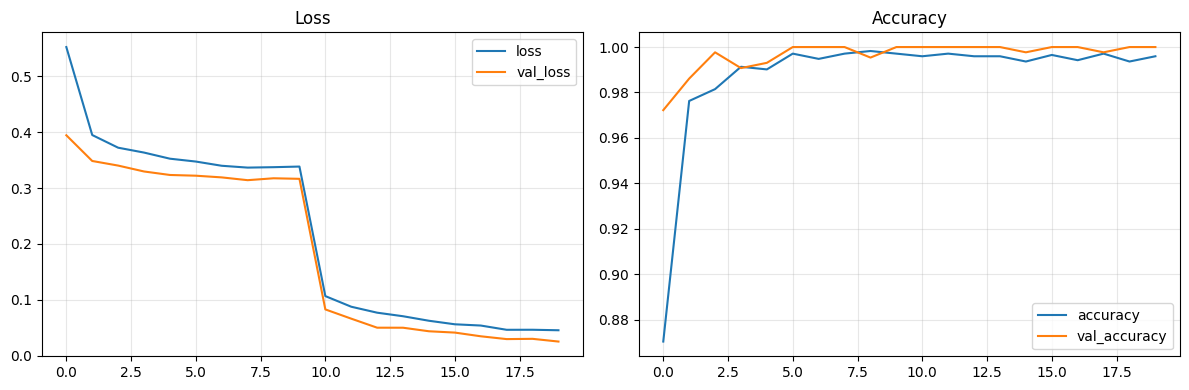

In [14]:
history = {}
for key in history_head.history:
    history[key] = history_head.history[key] + history_finetune.history[key]

history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss')
history_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Test loss: 0.4063
Test accuracy: 0.9537

              precision    recall  f1-score   support

       Amine       0.90      0.98      0.94       180
       Rifki       0.99      1.00      0.99       180
       Jakub       0.98      0.88      0.93       180

    accuracy                           0.95       540
   macro avg       0.96      0.95      0.95       540
weighted avg       0.96      0.95      0.95       540



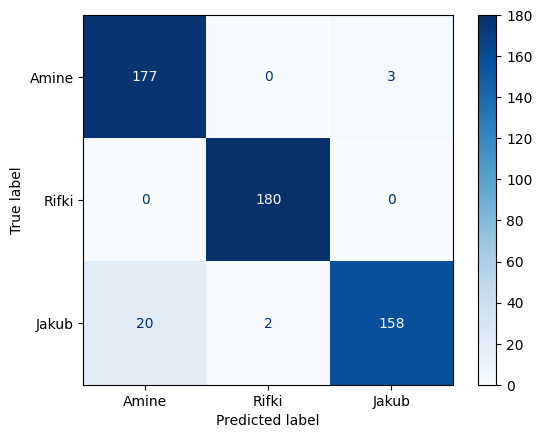

In [15]:
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

probabilities = model.predict(test_gen, verbose=0)
y_pred = np.argmax(probabilities, axis=1)
y_true = test_gen.classes

print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.show()

In [16]:
rifki_model = keras.models.load_model(MODEL_PATH)

rifki_test_df = test_df[test_df['label'].str.lower() == 'rifki'].reset_index(drop=True)
if rifki_test_df.empty:
    raise ValueError('No Rifki test images found in test_df')

rifki_test_gen = test_datagen.flow_from_dataframe(
    dataframe=rifki_test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    keep_aspect_ratio=True,
    class_mode='categorical',
    classes=CLASS_NAMES,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

rifki_loss, rifki_acc = rifki_model.evaluate(rifki_test_gen, verbose=0)
rifki_probabilities = rifki_model.predict(rifki_test_gen, verbose=0)
rifki_y_pred = np.argmax(rifki_probabilities, axis=1)
rifki_y_true = rifki_test_gen.classes
rifki_index = CLASS_NAMES.index('Rifki')
rifki_correct = int(np.sum(rifki_y_pred == rifki_index))
rifki_total = len(rifki_y_true)
rifki_recall = rifki_correct / rifki_total

print('Loaded model:', MODEL_PATH.resolve())
print(f'Rifki test samples: {rifki_total}')
print(f'Rifki-only test loss: {rifki_loss:.4f}')
print(f'Rifki-only test accuracy: {rifki_acc:.4f}')
print(f'Rifki recall: {rifki_recall:.4f} ({rifki_correct}/{rifki_total})')

rifki_pred_counts = (
    pd.Series([CLASS_NAMES[index] for index in rifki_y_pred], name='predicted_class')
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)
display(rifki_pred_counts.rename('count').reset_index())

print()
print(classification_report(
    rifki_y_true,
    rifki_y_pred,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    zero_division=0,
))

Found 180 validated image filenames belonging to 3 classes.
Loaded model: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\mobilenetv2_3class_center_crop_classifier.keras
Rifki test samples: 180
Rifki-only test loss: 0.3266
Rifki-only test accuracy: 1.0000
Rifki recall: 1.0000 (180/180)


,predicted_class,count
0,Amine,0
1,Rifki,180
2,Jakub,0



              precision    recall  f1-score   support

       Amine       0.00      0.00      0.00         0
       Rifki       1.00      1.00      1.00       180
       Jakub       0.00      0.00      0.00         0

    accuracy                           1.00       180
   macro avg       0.33      0.33      0.33       180
weighted avg       1.00      1.00      1.00       180



In [17]:
# Inference uses the full resized frame, so the notebook preview does the same.


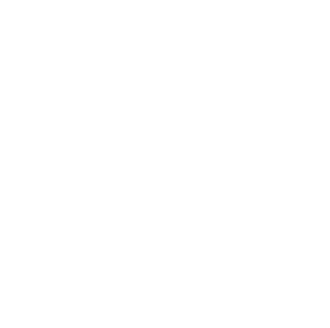

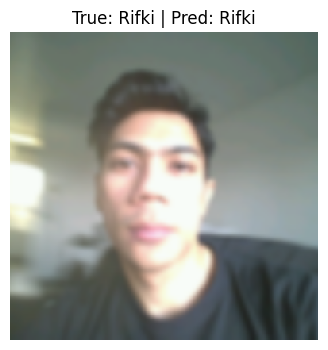

Amine: 0.0228
Rifki: 0.9601
Jakub: 0.0171

Saved model to: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\mobilenetv2_3class_center_crop_classifier.keras


In [18]:
index_to_class = {v: k for k, v in train_gen.class_indices.items()}
random_row = test_df.sample(1, random_state=random.randint(0, 10_000)).iloc[0]
sample_path = random_row['filepath']
plt.figure(figsize=(4, 4))
# plt.imshow(keras.utils.load_img(sample_path, target_size=IMAGE_SIZE, keep_aspect_ratio=True))
plt.axis('off')
plt.show()
# sample_path = "ceiling.png"
# sample_path = "image_20260311_200130.png"

image = keras.utils.load_img(sample_path, target_size=IMAGE_SIZE, keep_aspect_ratio=True)
array = keras.utils.img_to_array(image)
array = preprocess_input(array)
prediction = model.predict(np.expand_dims(array, axis=0), verbose=0)[0]
predicted_class = index_to_class[int(np.argmax(prediction))]

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.title(f'True: {random_row["label"]} | Pred: {predicted_class}')
plt.axis('off')
plt.show()

for class_name, score in zip(CLASS_NAMES, prediction):
    print(f'{class_name}: {score:.4f}')

print('\nSaved model to:', MODEL_PATH.resolve())

,filename,predicted_class,confidence,Amine,Rifki,Jakub
0,frame_20260430_082304_380155.png,Rifki,0.531558,0.395542,0.531558,0.072900
1,frame_20260430_082308_918605.png,Amine,0.456117,0.456117,0.454767,0.089116
2,frame_20260430_082711_280761.png,Rifki,0.791529,0.131948,0.791529,0.076523
3,frame_20260430_082722_628402.png,Rifki,0.639694,0.241487,0.639694,0.118820
4,frame_20260430_082740_789752.png,Rifki,0.421292,0.318290,0.421292,0.260419
...,...,...,...,...,...,...
233,frame_20260430_132524_629835.png,Jakub,0.784440,0.103045,0.112515,0.784440
234,frame_20260430_132526_890621.png,Jakub,0.571524,0.146977,0.281499,0.571524
235,frame_20260430_132529_149608.png,Jakub,0.445035,0.336625,0.218339,0.445035
236,frame_20260430_132531_396659.png,Jakub,0.757233,0.030567,0.212200,0.757233


Loaded model: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\mobilenetv2_3class_center_crop_classifier.keras
Folder: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\pred_capture
Images tested: 238
Prediction counts:
predicted_class
Amine     50
Rifki     76
Jakub    112
Name: count, dtype: int64


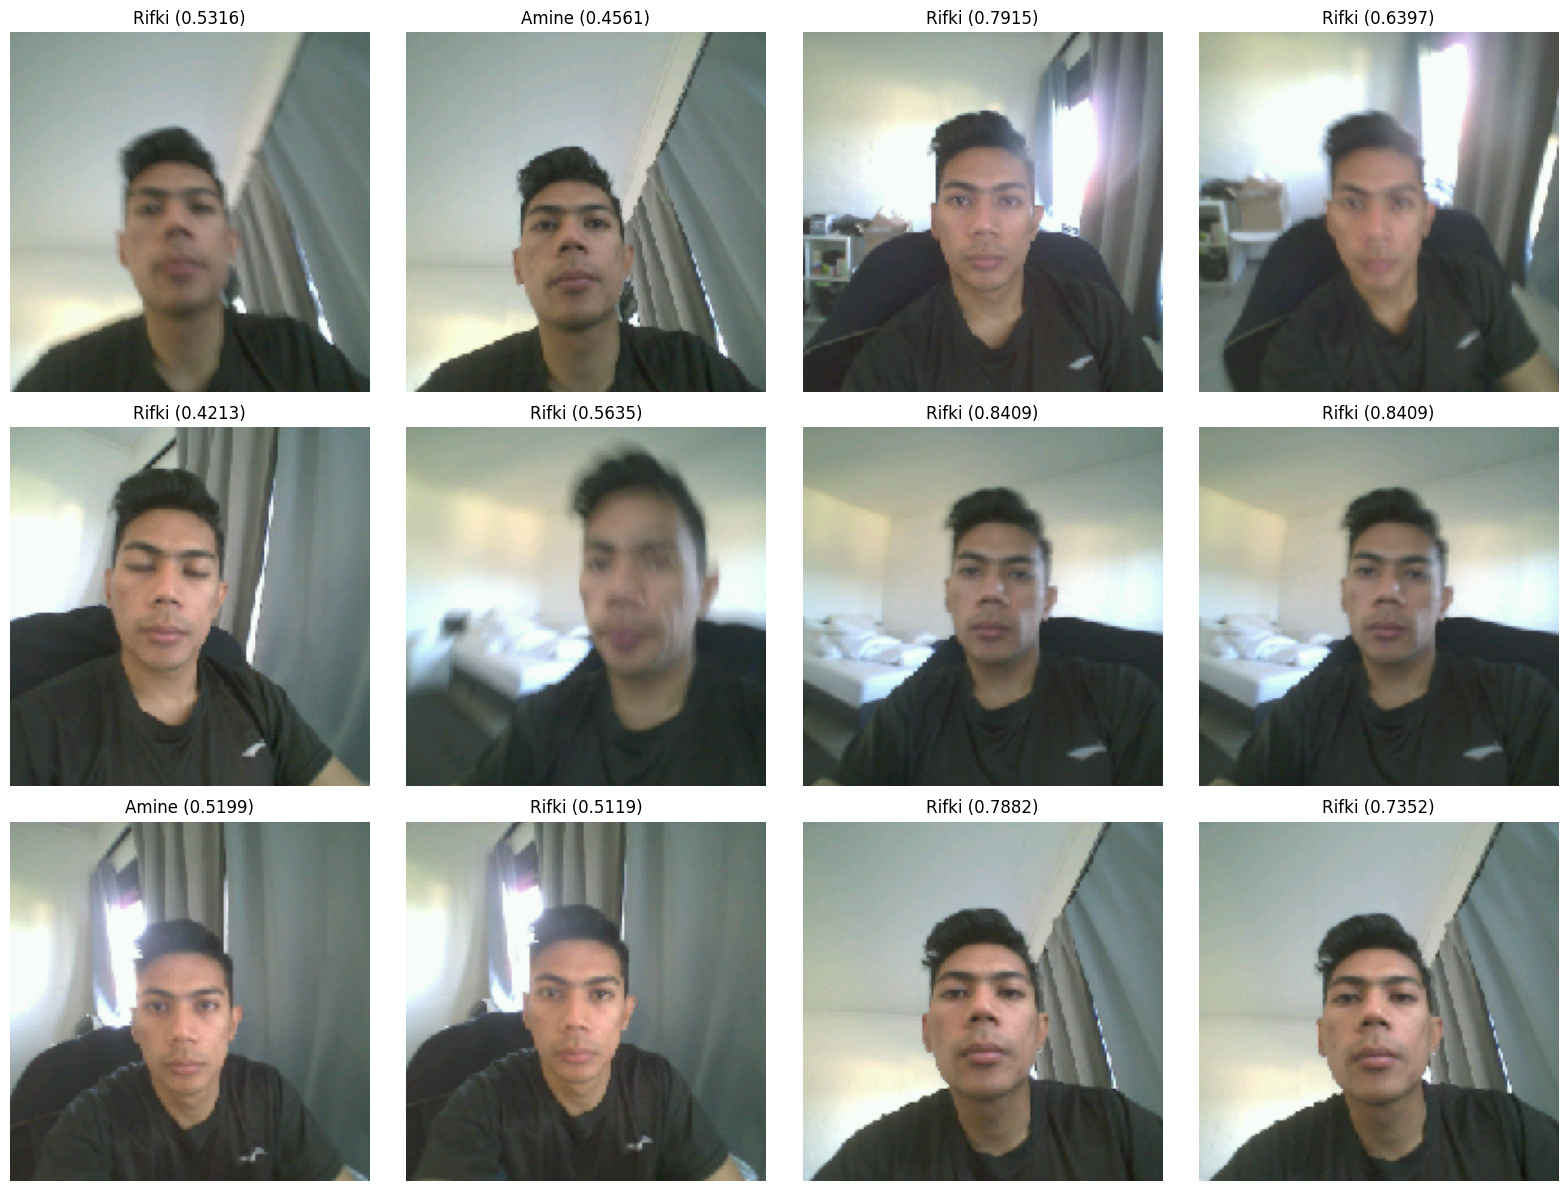

In [19]:
SINGLE_IMAGE_FOLDER = Path('pred_capture')  # Change this folder
VALID_IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp'}

folder_image_model = keras.models.load_model(MODEL_PATH)
single_image_folder = Path(SINGLE_IMAGE_FOLDER)
if not single_image_folder.exists():
    raise FileNotFoundError(f'Folder not found: {single_image_folder.resolve()}')

image_paths = sorted(
    path for path in single_image_folder.iterdir()
    if path.is_file() and path.suffix.lower() in VALID_IMAGE_EXTENSIONS
)
if not image_paths:
    raise ValueError(f'No images found in {single_image_folder.resolve()}')

arrays = []
for image_path in image_paths:
    image = keras.utils.load_img(image_path, target_size=IMAGE_SIZE, keep_aspect_ratio=True)
    array = keras.utils.img_to_array(image).astype(np.float32)
    arrays.append(preprocess_input(array))

probabilities = folder_image_model.predict(np.stack(arrays), verbose=0)
predicted_indices = np.argmax(probabilities, axis=1)

rows = []
for image_path, prediction, predicted_index in zip(image_paths, probabilities, predicted_indices):
    rows.append({
        'filename': image_path.name,
        'predicted_class': CLASS_NAMES[int(predicted_index)],
        'confidence': float(prediction[int(predicted_index)]),
        **{class_name: float(score) for class_name, score in zip(CLASS_NAMES, prediction)},
    })

results_df = pd.DataFrame(rows)
display(results_df)

print('Loaded model:', MODEL_PATH.resolve())
print('Folder:', single_image_folder.resolve())
print(f'Images tested: {len(image_paths)}')
print('Prediction counts:')
print(results_df['predicted_class'].value_counts().reindex(CLASS_NAMES, fill_value=0))

preview_count = min(12, len(image_paths))
cols = min(4, preview_count)
rows_count = int(np.ceil(preview_count / cols))
plt.figure(figsize=(4 * cols, 4 * rows_count))
for i, image_path in enumerate(image_paths[:preview_count], start=1):
    image = keras.utils.load_img(image_path, target_size=IMAGE_SIZE, keep_aspect_ratio=True)
    predicted_class = results_df.iloc[i - 1]['predicted_class']
    confidence = results_df.iloc[i - 1]['confidence']
    plt.subplot(rows_count, cols, i)
    plt.imshow(image)
    plt.title(f'{predicted_class} ({confidence:.4f})')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [20]:
model.summary()

Model: "MobileNetV2_3Class"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 mobilenetv2_0.35_160 (Funct  (None, 5, 5, 1280)       410208    
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout_1 (Dropout)         (None, 128)        

## Export Deterministic Training Subset

This section saves the preprocessed training subset used by the MobileNetV2 pipeline to `saved_model/x_train.npy` and `saved_model/y_train.npy` for later quantization.

In [21]:
VALIDATION_SPLIT = 0.2
X_TRAIN_PATH = MODEL_PATH.parent / 'x_train.npy'
Y_TRAIN_PATH = MODEL_PATH.parent / 'y_train.npy'


def make_training_subset(train_df: pd.DataFrame) -> pd.DataFrame:
    split_index = int(len(train_df) * VALIDATION_SPLIT)
    return train_df.iloc[split_index:].reset_index(drop=True)


def load_and_preprocess_images(train_subset: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    class_to_index = {name: idx for idx, name in enumerate(CLASS_NAMES)}

    x_train = []
    y_train = []

    for row in train_subset.itertuples(index=False):
        image = keras.utils.load_img(row.filepath, target_size=IMAGE_SIZE, keep_aspect_ratio=True)
        array = keras.utils.img_to_array(image).astype(np.float32)
        array = preprocess_input(array)

        x_train.append(array)
        y_train.append(class_to_index[row.label])

    return np.stack(x_train).astype(np.float32), np.array(y_train, dtype=np.int32)


MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
train_subset = make_training_subset(train_df)
x_train, y_train = load_and_preprocess_images(train_subset)

np.save(X_TRAIN_PATH, x_train)
np.save(Y_TRAIN_PATH, y_train)

print(f'Saved training subset: {len(train_subset)} images')
print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'Saved: {X_TRAIN_PATH.resolve()}')
print(f'Saved: {Y_TRAIN_PATH.resolve()}')


Saved training subset: 1728 images
x_train shape: (1728, 160, 160, 3)
y_train shape: (1728,)
Saved: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\x_train.npy
Saved: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\y_train.npy
